# Exercise 1: PCA for Real Estate Analysis

Maggie is a real-estate agent puzzled about why some properties have not been sold for more than 6 months. We apply PCA to a housing dataset to identify the key drivers of slow sales.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Load California Housing Dataset

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target
print('Shape:', df.shape)
print('\nFeatures:', list(df.columns))
df.head()

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory: Mark Slow-Selling Properties

Properties in the top price quartile are considered 'slow to sell' (high price relative to market).

In [3]:
threshold = df['Price'].quantile(0.75)
df['slow_sell'] = (df['Price'] >= threshold).astype(int)
print(f'Slow-sell threshold (75th percentile): {threshold:.2f}')
print(f'Slow-sell properties: {df["slow_sell"].sum()} / {len(df)}')

Slow-sell threshold (75th percentile): 2.65
Slow-sell properties: 5160 / 20640


## Standardize Features

In [4]:
features = housing.feature_names
x = df[features].values
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

## Apply PCA

In [5]:
pca = PCA()
pca.fit(x_scaled)

print('Explained Variance Ratio:')
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_))):
    print(f'  PC{i+1}: {var:.4f}  (cumulative: {cum:.4f})')

Explained Variance Ratio:
  PC1: 0.2534  (cumulative: 0.2534)
  PC2: 0.2352  (cumulative: 0.4885)
  PC3: 0.1589  (cumulative: 0.6474)
  PC4: 0.1289  (cumulative: 0.7763)
  PC5: 0.1254  (cumulative: 0.9017)
  PC6: 0.0824  (cumulative: 0.9841)
  PC7: 0.0102  (cumulative: 0.9943)
  PC8: 0.0057  (cumulative: 1.0000)


## Scree Plot

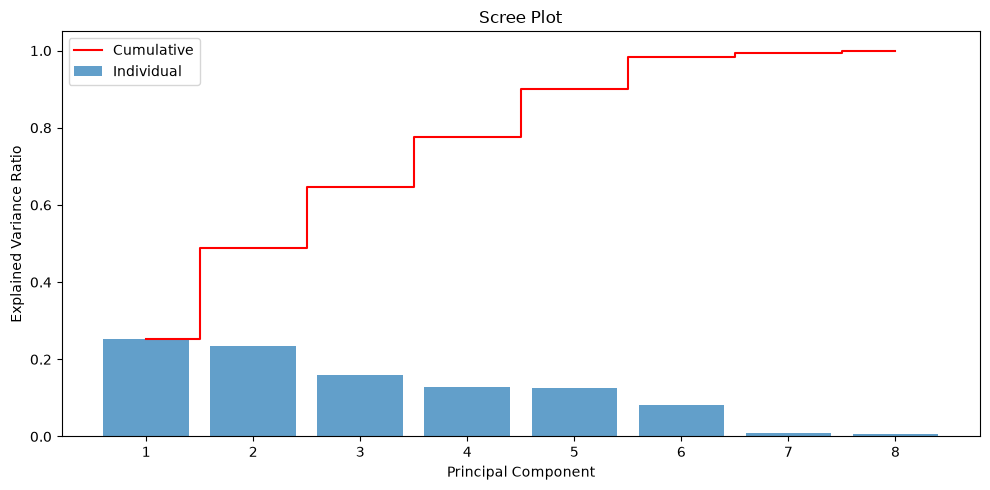

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.xticks(range(1, len(features) + 1))
plt.tight_layout()
plt.show()

## Loadings Matrix

In [7]:
loadings = pd.DataFrame(pca.components_.T, index=features, columns=[f'PC{i+1}' for i in range(len(features))])
print('PCA Loadings (first 4 PCs):')
print(loadings.iloc[:, :4].round(3))

PCA Loadings (first 4 PCs):
              PC1    PC2    PC3    PC4
MedInc      0.077  0.230  0.218  0.885
HouseAge    0.007 -0.261 -0.628  0.110
AveRooms    0.439  0.547 -0.064  0.046
AveBedrms   0.400  0.502 -0.192 -0.338
Population -0.172  0.101  0.650 -0.283
AveOccup   -0.015  0.003  0.158 -0.005
Latitude    0.568 -0.374  0.193 -0.062
Longitude  -0.537  0.422 -0.181 -0.060


## 2D Biplot

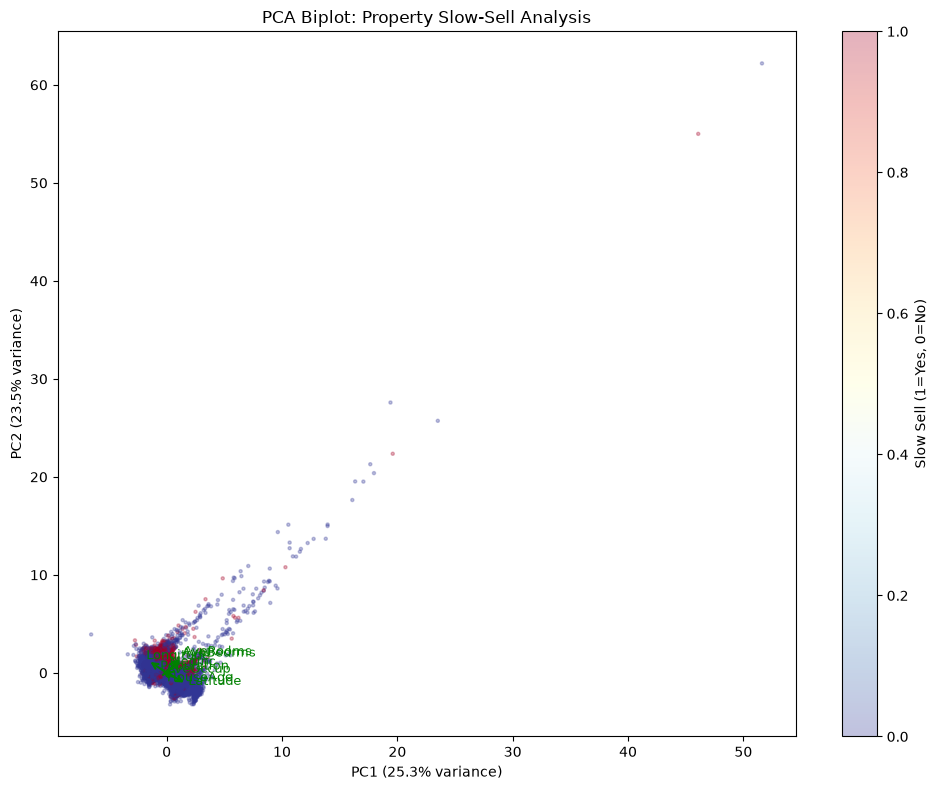

In [8]:
x_pca = pca.transform(x_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(x_pca[:, 0], x_pca[:, 1], c=df['slow_sell'], cmap='RdYlBu_r', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Biplot: Property Slow-Sell Analysis')

# Plot feature vectors
for i, feature in enumerate(features):
    ax.annotate('', xy=(pca.components_[0, i] * 3, pca.components_[1, i] * 3), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
    ax.text(pca.components_[0, i] * 3.3, pca.components_[1, i] * 3.3, feature,
            color='green', fontsize=9)

plt.colorbar(scatter, label='Slow Sell (1=Yes, 0=No)')
plt.tight_layout()
plt.show()

## Conclusion

The PCA reveals that **MedInc** (median income) and **AveRooms** are the dominant factors in PC1, capturing the most variance. Properties with high prices (slow sellers) tend to cluster in regions of high PC1, driven primarily by high income levels and larger home sizes. The second component highlights geographic factors (Latitude, Longitude). These insights help Maggie understand that pricing and location are the primary drivers of slow sales.